In [1]:
#imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect('chinook.db')

### Customer Distribution by Country

**Question:**  
Which countries have the most customers in the Chinook music store database?

In [3]:
query = """
SELECT Country, COUNT(*) As NumbersOfCustomers
FROM customers
GROUP BY Country
ORDER BY NumbersOfCustomers DESC
LIMIT 10;
"""

In [4]:
df_customers_country = pd.read_sql(query,conn)
df_customers_country.head(10)

,Country,NumbersOfCustomers
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_296\1035205931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NumbersOfCustomers', y='Country', data=df_customers_country, palette='viridis')


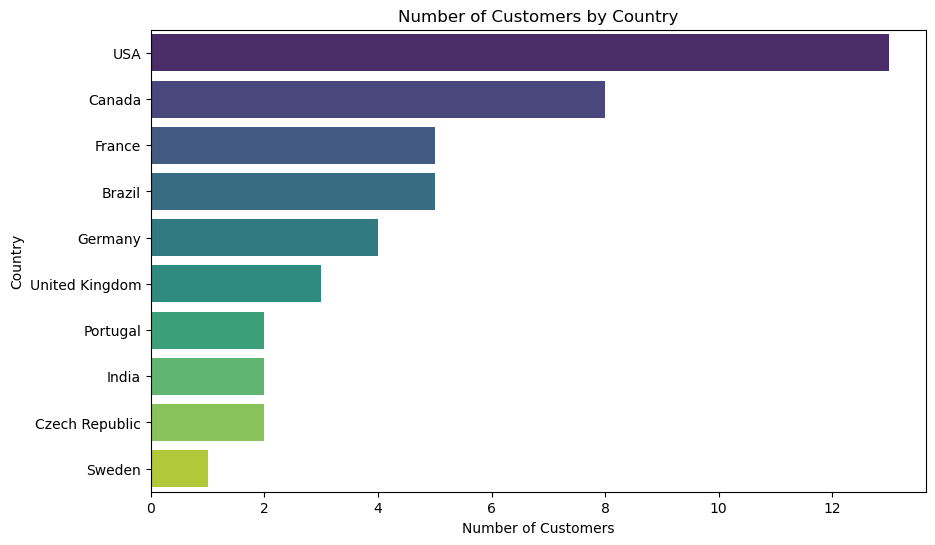

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x='NumbersOfCustomers', y='Country', data=df_customers_country, palette='viridis')
plt.title('Number of Customers by Country')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.show()

**Insight**

The United States has the highest number of customers in the dataset with **13 customers**, making it the store's largest market. This suggests that marketing campaigns, promotions, and customer retention strategies may have the greatest impact if focused on this region.

In [6]:
query = """
SELECT COUNT(DISTINCT Country) AS NumberOfCountries
FROM customers;
"""
pd.read_sql(query, conn)

,NumberOfCountries
0,24


### Revenue by Country

**Question:** 
Which countries generate the most revenue for the Chinook music store?

In [7]:
query = """
SELECT BillingCountry,
       SUM(Total) AS TotalRevenue
FROM invoices
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

df_revenue_country = pd.read_sql(query, conn)

df_revenue_country

,BillingCountry,TotalRevenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_296\2423439994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalRevenue', y='BillingCountry', data=df_revenue_country, palette='coolwarm')


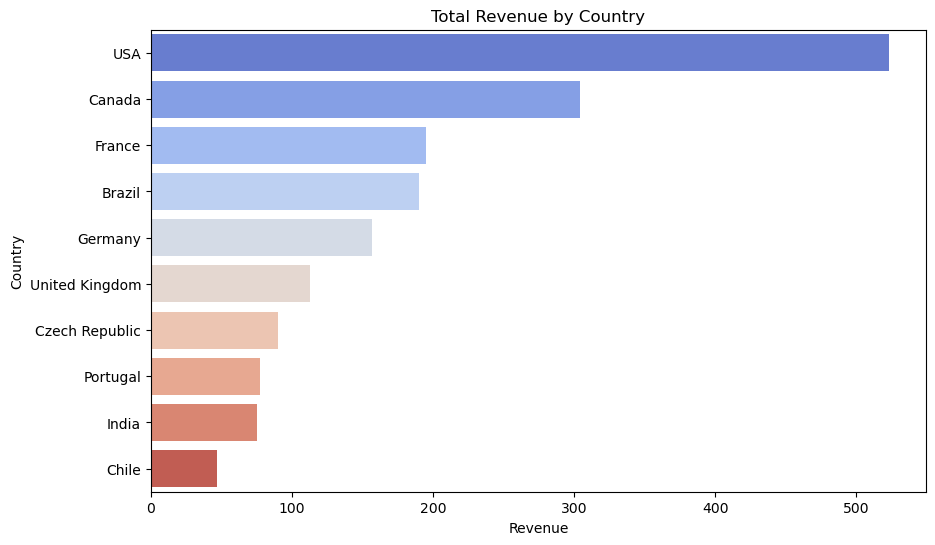

In [8]:

plt.figure(figsize=(10,6))
sns.barplot(x='TotalRevenue', y='BillingCountry', data=df_revenue_country, palette='coolwarm')
plt.title('Total Revenue by Country')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.show()

**Insight**

The USA generates the most revenue, which aligns with it having the most customers. However, the Czech Republic ranks higher in revenue than expected given only 2 customers, suggesting that those customers are high-value buyers.

### Top-Spending Customers

**Question:**  
Who are the highest-spending customers in the Chinook music store?


In [9]:
query = """
SELECT 
    customers.FirstName || ' ' || customers.LastName AS FullName,
    customers.Country,
    SUM(invoices.Total) AS TotalSpend
FROM customers
INNER JOIN invoices
ON customers.CustomerId = invoices.CustomerId
GROUP BY customers.CustomerId
ORDER BY TotalSpend DESC
LIMIT 10;
"""
df_top_customers = pd.read_sql(query,conn)
df_top_customers

,FullName,Country,TotalSpend
0,Helena Holý,Czech Republic,49.62
1,Richard Cunningham,USA,47.62
2,Luis Rojas,Chile,46.62
3,Ladislav Kovács,Hungary,45.62
4,Hugh O'Reilly,Ireland,45.62
5,Frank Ralston,USA,43.62
6,Julia Barnett,USA,43.62
7,Fynn Zimmermann,Germany,43.62
8,Astrid Gruber,Austria,42.62
9,Victor Stevens,USA,42.62


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_296\1522568080.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalSpend', y='FullName', data=df_top_customers, palette='magma')


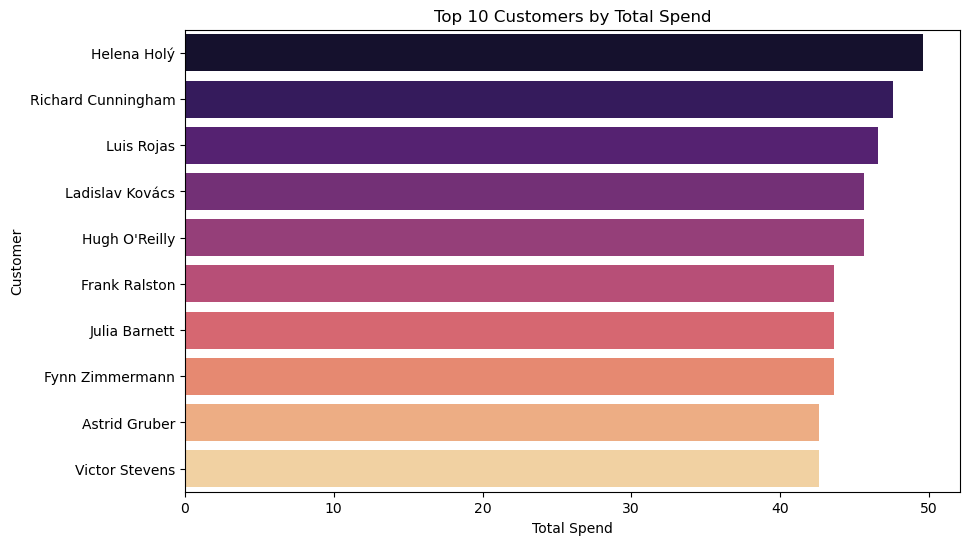

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x='TotalSpend', y='FullName', data=df_top_customers, palette='magma')
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Total Spend')
plt.ylabel('Customer')
plt.show()

**Insight:**  

The top-spending customer is **Helena Holy** from the Czech Republic.  
Despite having only 2 customers, Czech Republic appears higher in revenue rankings due to high individual spending.  


### Revenue by Music Genre

**Question:**  
Which music genres generate the most revenue in the Chinook music store?


In [11]:
query = """
SELECT 
    genres.Name AS Genre,
    SUM(invoice_items.UnitPrice * invoice_items.Quantity) AS Revenue
FROM invoice_items
INNER JOIN tracks
    ON invoice_items.TrackId = tracks.TrackId
INNER JOIN genres
    ON tracks.GenreId = genres.GenreId
GROUP BY genres.Name
ORDER BY Revenue DESC
LIMIT 10;
"""
df_genre_revenue = pd.read_sql(query,conn)
df_genre_revenue

,Genre,Revenue
0,Rock,826.65
1,Latin,382.14
2,Metal,261.36
3,Alternative & Punk,241.56
4,TV Shows,93.53
5,Jazz,79.20
6,Blues,60.39
7,Drama,57.71
8,R&B/Soul,40.59
9,Classical,40.59


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_296\2389233184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Revenue', y='Genre', data=df_genre_revenue, palette='Set2')


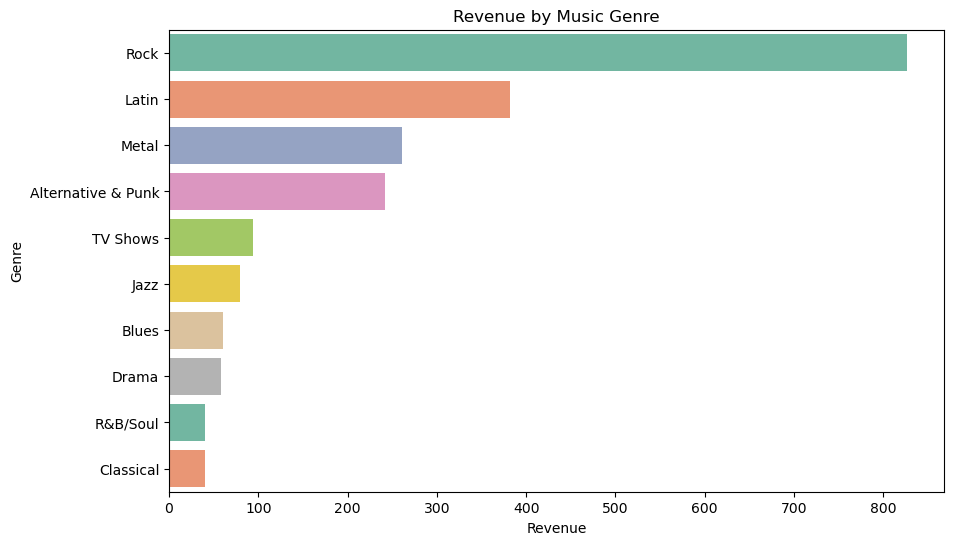

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x='Revenue', y='Genre', data=df_genre_revenue, palette='Set2')
plt.title('Revenue by Music Genre')
plt.xlabel('Revenue')
plt.ylabel('Genre')
plt.show()

**Insight:**  

The top three revenue-generating genres are **Rock, Latin, and Metal**.  


### Revenue Trends Over Time

**Question:**  
Which months generate the most revenue for the Chinook music store?

In [13]:
query = """
SELECT STRFTIME('%Y-%m', InvoiceDate) AS YearMonth,
       SUM(Total) AS Revenue
FROM invoices
GROUP BY YearMonth
ORDER BY Revenue DESC;
"""
pd.read_sql(query,conn)

,YearMonth,Revenue
0,2010-01,52.62
1,2011-04,51.62
2,2011-06,50.62
3,2013-11,49.62
4,2012-08,47.62
5,2012-09,46.71
6,2010-02,46.62
7,2010-03,44.62
8,2012-10,42.62
9,2011-05,42.62


In [14]:
query = """
SELECT STRFTIME('%m', InvoiceDate) AS Month, STRFTIME('%Y', InvoiceDate) AS Year,
       SUM(Total) AS Revenue
FROM invoices
GROUP BY Year, Month
"""
pd.read_sql(query,conn)

,Month,Year,Revenue
0,01,2009,35.64
1,02,2009,37.62
2,03,2009,37.62
3,04,2009,37.62
4,05,2009,37.62
5,06,2009,37.62
6,07,2009,37.62
7,08,2009,37.62
8,09,2009,37.62
9,10,2009,37.62


In [15]:
query = """
SELECT STRFTIME('%m', InvoiceDate) AS Month,
       SUM(Total) AS Revenue
FROM invoices
GROUP BY Month
ORDER BY Month;
"""
df_revenue_month = pd.read_sql(query,conn)
df_revenue_month

,Month,Revenue
0,01,201.12
1,02,187.20
2,03,195.10
3,04,198.14
4,05,193.10
5,06,201.10
6,07,190.10
7,08,198.10
8,09,196.20
9,10,193.10


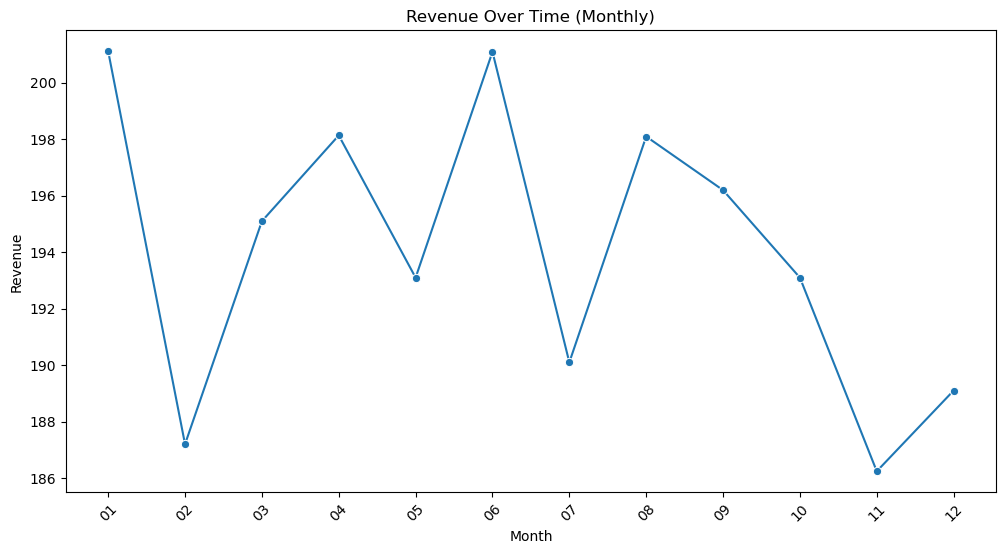

In [16]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='Revenue', data=df_revenue_month, marker='o')
plt.title('Revenue Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

**Insight:**  

The month with the highest revenue is January in the year 2010
This analysis reveals **seasonal trends** certain months consistently outperform others.  
Understanding these patterns allows the store to optimize promotions, stock, and marketing campaigns for peak periods.

### Top-Selling Tracks

**Question:**  
Which tracks are purchased the most in the Chinook music store?



In [17]:
query="""
SELECT  tracks.Name AS Track, genres.Name AS Genre, SUM(invoice_items.Quantity) as TotalSold
FROM invoice_items
INNER JOIN tracks
ON invoice_items.trackId=tracks.trackId
INNER JOIN genres
ON tracks.GenreId=genres.GenreId
GROUP BY tracks.Name
ORDER BY TotalSold DESC
LIMIT 10;
"""
df_top_tracks = pd.read_sql(query,conn)
df_top_tracks

,Track,Genre,TotalSold
0,The Trooper,Rock,5
1,Untitled,Rock,4
2,The Number Of The Beast,Metal,4
3,Sure Know Something,Rock,4
4,Hallowed Be Thy Name,Metal,4
5,Eruption,Rock,4
6,Where Eagles Dare,Metal,3
7,Welcome Home (Sanitarium),Metal,3
8,Sweetest Thing,Rock,3
9,Surrender,Rock,3


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_296\2530915744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalSold', y='Track', data=df_top_tracks, palette='cool')


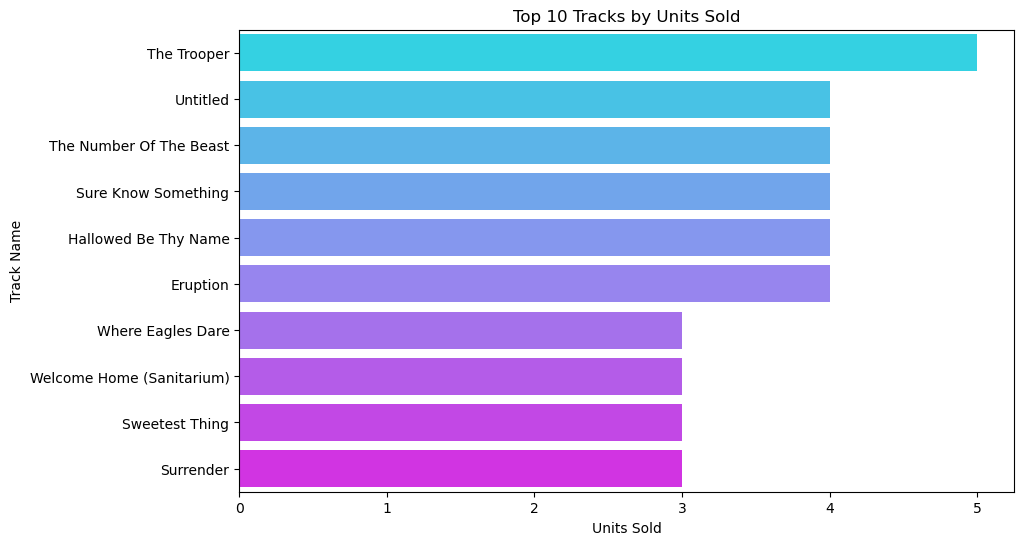

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x='TotalSold', y='Track', data=df_top_tracks, palette='cool')
plt.title('Top 10 Tracks by Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Track Name')
plt.show()

**Insight:**  

The top 10 tracks are primarily in the **Rock and Metal** genres, confirming why these genres dominate revenue.  
Latin is not represented in the top 10 tracks, yet it is the **second-highest revenue genre**, indicating that its revenue comes from **many different tracks purchased across multiple customers** rather than single hit tracks.

### Customer Purchase Frequency

**Question:**  
Which customers make the most purchases in the Chinook music store?


In [19]:
query = """
SELECT 
    customers.FirstName || ' ' || customers.LastName AS FullName,
    customers.Country,
    COUNT(invoices.InvoiceId) AS PurchaseCount
FROM customers
INNER JOIN invoices
    ON customers.CustomerId = invoices.CustomerId
GROUP BY customers.CustomerId
ORDER BY PurchaseCount DESC
LIMIT 10;
"""

df_purchase_frequency = pd.read_sql(query, conn)
df_purchase_frequency

,FullName,Country,PurchaseCount
0,Luís Gonçalves,Brazil,7
1,Leonie Köhler,Germany,7
2,François Tremblay,Canada,7
3,Bjørn Hansen,Norway,7
4,František Wichterlová,Czech Republic,7
5,Helena Holý,Czech Republic,7
6,Astrid Gruber,Austria,7
7,Daan Peeters,Belgium,7
8,Kara Nielsen,Denmark,7
9,Eduardo Martins,Brazil,7


C:\Users\Mary-Jane\AppData\Local\Temp\ipykernel_296\3431443097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PurchaseCount', y='FullName', data=df_purchase_frequency, palette='autumn')


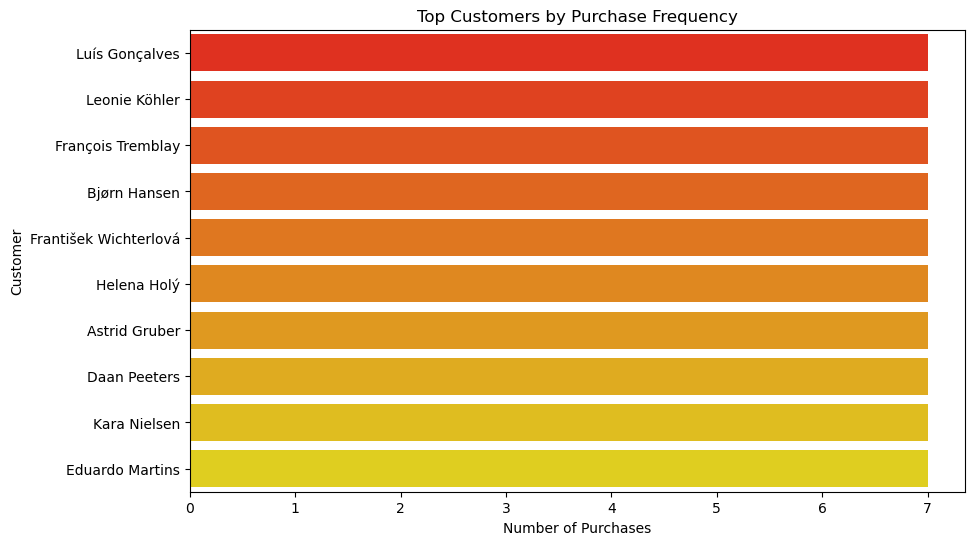

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x='PurchaseCount', y='FullName', data=df_purchase_frequency, palette='autumn')
plt.title('Top Customers by Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Customer')
plt.show()

**Insight:**  

Many customers are tied with the highest purchase count of 7, showing that **loyalty is distributed across multiple customers**.  
Top spenders (like Helena Holy) do not necessarily make the most purchases.


### Number of Purchases by Month

**Question:**  
How many purchases occur each month in the Chinook music store?


In [21]:
query = """
SELECT STRFTIME('%m', InvoiceDate) AS Month, STRFTIME('%Y', InvoiceDate) AS Year,
       COUNT(invoiceId) AS TotalPurchase,  SUM(Total) AS Revenue
FROM invoices
GROUP BY Month, Year
"""
df_purchases_month = pd.read_sql(query,conn)
df_purchases_month

,Month,Year,TotalPurchase,Revenue
0,01,2009,6,35.64
1,01,2010,7,52.62
2,01,2011,7,37.62
3,01,2012,7,37.62
4,01,2013,7,37.62
5,02,2009,7,37.62
6,02,2010,7,46.62
7,02,2011,7,37.62
8,02,2012,7,37.62
9,02,2013,5,27.72


In [22]:
#avg purchase per month
query = """
SELECT 
    Month,
    AVG(MonthlyCount) AS AvgPurchases,
    SUM(Total) AS Revenue
FROM (
    SELECT 
        STRFTIME('%Y', InvoiceDate) AS Year,
        STRFTIME('%m', InvoiceDate) AS Month,
        COUNT(InvoiceId) AS MonthlyCount,
        SUM(Total) AS Total
    FROM invoices
    GROUP BY Year, Month
) AS monthly_data
GROUP BY Month
ORDER BY Month;
"""
df_avg_purchases_month = pd.read_sql(query,conn)
df_avg_purchases_month

,Month,AvgPurchases,Revenue
0,01,6.8,201.12
1,02,6.6,187.20
2,03,7.0,195.10
3,04,6.6,198.14
4,05,7.0,193.10
5,06,7.0,201.10
6,07,7.0,190.10
7,08,7.0,198.10
8,09,6.6,196.20
9,10,7.0,193.10


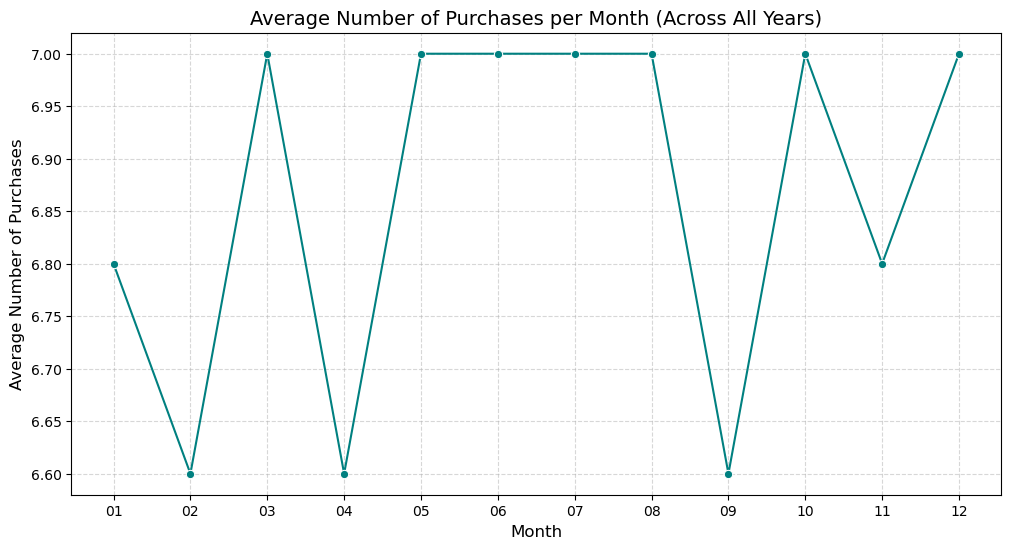

In [23]:
df_avg_purchases_month = df_avg_purchases_month.sort_values('Month')

plt.figure(figsize=(12,6))
sns.lineplot(
    x='Month', 
    y='AvgPurchases', 
    data=df_avg_purchases_month, 
    marker='o', 
    color='teal'
)
plt.title('Average Number of Purchases per Month (Across All Years)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Number of Purchases', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**  

The number of purchases per month highlights **high-activity periods** in the store.  
months purchase frequency ranges from 5 to 7, while the revenue changes across months eventhough number of purchases remain the same